# Hands-On Feature Engineering with Titanic Dataset

In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
df=sns.load_dataset('titanic')
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# 1. 🏷️ Encoding Categorical Variables
##  1.1 Label Encoding (Ordinal Example: 'class')

In [22]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['Encoded_class']=encoder.fit_transform(
    df['class'])
df[['class','Encoded_class']]

,class,Encoded_class
0,Third,2
1,First,0
2,Third,2
3,First,0
4,Third,2
...,...,...
886,Second,1
887,First,0
888,Third,2
889,First,0


## 1.2 One-Hot Encoding (Nominal Example: 'sex')

In [23]:
df_encoded=pd.get_dummies(df,
                columns=['sex'],
                         drop_first=True)
df_encoded[['sex_male']].head()


,sex_male
0,True
1,False
2,False
3,False
4,True


## 1.3 Target Encoding (Example: 'embarked' vs survival)

In [24]:
target_mean=df.groupby('embarked')['survived'].mean()
df['embarked_encoded']=df['embarked'].map(target_mean)
df[['embarked_encoded','embarked']].head()

,embarked_encoded,embarked
0,0.336957,S
1,0.553571,C
2,0.336957,S
3,0.336957,S
4,0.336957,S


#### 2. 🔄 Feature Transformation

### 2.1 Log Transformation (Skewed feature: 'fare')

<Axes: xlabel='fare', ylabel='Count'>

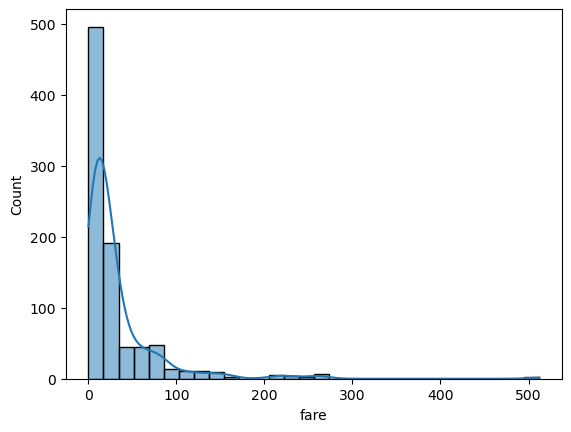

In [25]:
sns.histplot(df['fare'], kde=True, bins=30)

In [26]:
df['fare_log']=np.log1p(df['fare'])

<Axes: xlabel='fare_log', ylabel='Count'>

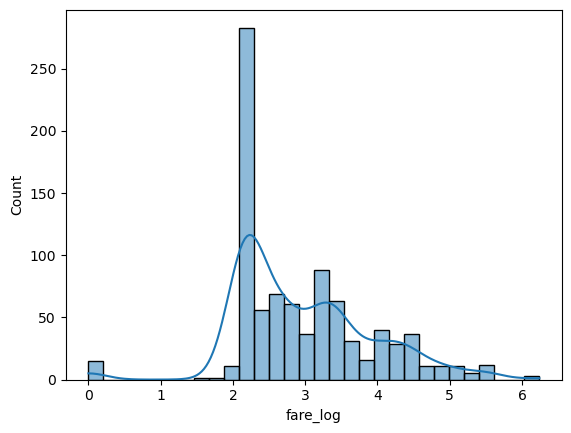

In [27]:
sns.histplot(df['fare_log'], kde=True, bins=30)

### 2.2 Polynomial Features (Age)

<Axes: xlabel='age_sqrt', ylabel='Count'>

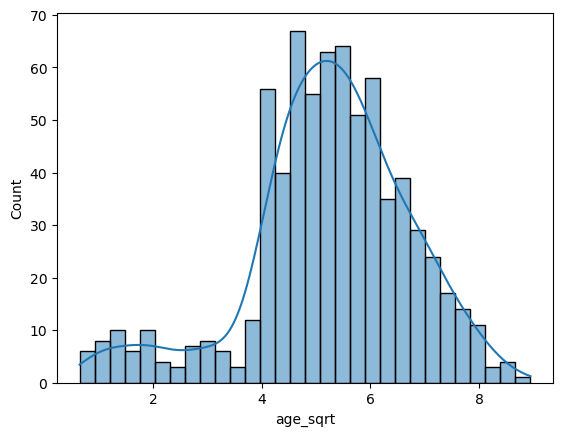

In [28]:
df['age_sqrt']=np.sqrt(df['age'])
sns.histplot(df['age_sqrt'], kde=True, bins=30)

### 2.3 Yeo-Johnson Transformation (Fare)

In [30]:
from sklearn.preprocessing import PowerTransformer
df['fare_yj']=PowerTransformer(method='yeo-johnson').fit_transform(df[['fare']])
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Encoded_class,embarked_encoded,fare_log,age_sqrt,fare_yj
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2,0.336957,2.110213,4.690416,-0.878820
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,0,0.553571,4.280593,6.164414,1.336651
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,2,0.336957,2.188856,5.099020,-0.790065
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,0,0.336957,3.990834,5.916080,1.067352
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,2,0.336957,2.202765,5.916080,-0.774439


<Axes: xlabel='fare_yj', ylabel='Count'>

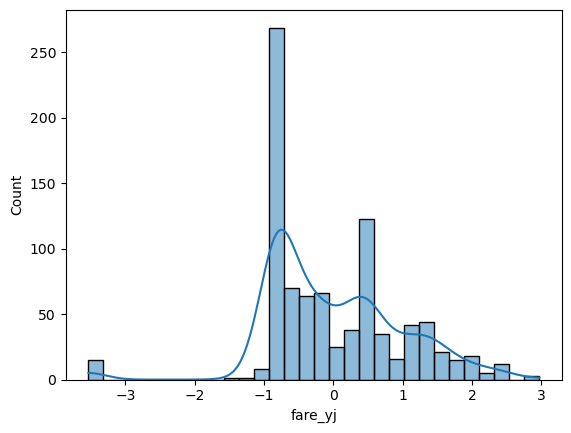

In [32]:
sns.histplot(df['fare_yj'], kde=True, bins=30)

# Box Cox Method

In [35]:
from sklearn.preprocessing import PowerTransformer
df['fare_box']=PowerTransformer(method='box-cox').fit_transform(df[['fare']]+1)
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,...,deck,embark_town,alive,alone,Encoded_class,embarked_encoded,fare_log,age_sqrt,fare_yj,fare_box
0,0,3,male,22.0,1,0,7.2500,S,Third,man,...,NaN,Southampton,no,False,2,0.336957,2.110213,4.690416,-0.878820,-0.878820
1,1,1,female,38.0,1,0,71.2833,C,First,woman,...,C,Cherbourg,yes,False,0,0.553571,4.280593,6.164414,1.336651,1.336651
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,...,NaN,Southampton,yes,True,2,0.336957,2.188856,5.099020,-0.790065,-0.790065
3,1,1,female,35.0,1,0,53.1000,S,First,woman,...,C,Southampton,yes,False,0,0.336957,3.990834,5.916080,1.067352,1.067352
4,0,3,male,35.0,0,0,8.0500,S,Third,man,...,NaN,Southampton,no,True,2,0.336957,2.202765,5.916080,-0.774439,-0.774439


# Data Handling

In [36]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,...,deck,embark_town,alive,alone,Encoded_class,embarked_encoded,fare_log,age_sqrt,fare_yj,fare_box
0,0,3,male,22.0,1,0,7.2500,S,Third,man,...,NaN,Southampton,no,False,2,0.336957,2.110213,4.690416,-0.878820,-0.878820
1,1,1,female,38.0,1,0,71.2833,C,First,woman,...,C,Cherbourg,yes,False,0,0.553571,4.280593,6.164414,1.336651,1.336651
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,...,NaN,Southampton,yes,True,2,0.336957,2.188856,5.099020,-0.790065,-0.790065
3,1,1,female,35.0,1,0,53.1000,S,First,woman,...,C,Southampton,yes,False,0,0.336957,3.990834,5.916080,1.067352,1.067352
4,0,3,male,35.0,0,0,8.0500,S,Third,man,...,NaN,Southampton,no,True,2,0.336957,2.202765,5.916080,-0.774439,-0.774439


In [37]:
#only load numeric columms
df1=df.select_dtypes(include=np.number)
df1.head()


,survived,pclass,age,sibsp,parch,fare,Encoded_class,embarked_encoded,fare_log,age_sqrt,fare_yj,fare_box
0,0,3,22.0,1,0,7.2500,2,0.336957,2.110213,4.690416,-0.878820,-0.878820
1,1,1,38.0,1,0,71.2833,0,0.553571,4.280593,6.164414,1.336651,1.336651
2,1,3,26.0,0,0,7.9250,2,0.336957,2.188856,5.099020,-0.790065,-0.790065
3,1,1,35.0,1,0,53.1000,0,0.336957,3.990834,5.916080,1.067352,1.067352
4,0,3,35.0,0,0,8.0500,2,0.336957,2.202765,5.916080,-0.774439,-0.774439


In [40]:
#only load categorical columns
df1=df.select_dtypes(include='object')
df1.head()

,sex,embarked,who,embark_town,alive
0,male,S,man,Southampton,no
1,female,C,woman,Cherbourg,yes
2,female,S,woman,Southampton,yes
3,female,S,woman,Southampton,yes
4,male,S,man,Southampton,no


# Handling missing values

In [43]:
from sklearn.impute import SimpleImputer
df['age_mean']=SimpleImputer(strategy='mean').fit_transform(df[['age']])
df.tail()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,...,embark_town,alive,alone,Encoded_class,embarked_encoded,fare_log,age_sqrt,fare_yj,fare_box,age_mean
886,0,2,male,27.0,0,0,13.00,S,Second,man,...,Southampton,no,True,1,0.336957,2.639057,5.196152,-0.294907,-0.294907,27.000000
887,1,1,female,19.0,0,0,30.00,S,First,woman,...,Southampton,yes,True,0,0.336957,3.433987,4.358899,0.527906,0.527906,19.000000
888,0,3,female,NaN,1,2,23.45,S,Third,woman,...,Southampton,no,False,2,0.336957,3.196630,NaN,0.288885,0.288885,29.699118
889,1,1,male,26.0,0,0,30.00,C,First,man,...,Cherbourg,yes,True,0,0.553571,3.433987,5.099020,0.527906,0.527906,26.000000
890,0,3,male,32.0,0,0,7.75,Q,Third,man,...,Queenstown,no,True,2,0.389610,2.169054,5.656854,-0.812349,-0.812349,32.000000


In [44]:
from sklearn.impute import SimpleImputer
df['age_median']=SimpleImputer(strategy='median').fit_transform(df[['age']])
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,...,alive,alone,Encoded_class,embarked_encoded,fare_log,age_sqrt,fare_yj,fare_box,age_mean,age_median
886,0,2,male,27.0,0,0,13.00,S,Second,man,...,no,True,1,0.336957,2.639057,5.196152,-0.294907,-0.294907,27.000000,27.0
887,1,1,female,19.0,0,0,30.00,S,First,woman,...,yes,True,0,0.336957,3.433987,4.358899,0.527906,0.527906,19.000000,19.0
888,0,3,female,NaN,1,2,23.45,S,Third,woman,...,no,False,2,0.336957,3.196630,NaN,0.288885,0.288885,29.699118,28.0
889,1,1,male,26.0,0,0,30.00,C,First,man,...,yes,True,0,0.553571,3.433987,5.099020,0.527906,0.527906,26.000000,26.0
890,0,3,male,32.0,0,0,7.75,Q,Third,man,...,no,True,2,0.389610,2.169054,5.656854,-0.812349,-0.812349,32.000000,32.0


In [45]:
from sklearn.impute import SimpleImputer
df['age_mode']=SimpleImputer(strategy='most_frequent').fit_transform(df[['age']])
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,...,alone,Encoded_class,embarked_encoded,fare_log,age_sqrt,fare_yj,fare_box,age_mean,age_median,age_mode
886,0,2,male,27.0,0,0,13.00,S,Second,man,...,True,1,0.336957,2.639057,5.196152,-0.294907,-0.294907,27.000000,27.0,27.0
887,1,1,female,19.0,0,0,30.00,S,First,woman,...,True,0,0.336957,3.433987,4.358899,0.527906,0.527906,19.000000,19.0,19.0
888,0,3,female,NaN,1,2,23.45,S,Third,woman,...,False,2,0.336957,3.196630,NaN,0.288885,0.288885,29.699118,28.0,24.0
889,1,1,male,26.0,0,0,30.00,C,First,man,...,True,0,0.553571,3.433987,5.099020,0.527906,0.527906,26.000000,26.0,26.0
890,0,3,male,32.0,0,0,7.75,Q,Third,man,...,True,2,0.389610,2.169054,5.656854,-0.812349,-0.812349,32.000000,32.0,32.0


In [ ]:
#
import SimpleImputer
SimpleImputer(startegy='constant',fill_value=0).fit_transform(df[['age']])

# 3. 📉 Feature Extraction

### 3.1 PCA (on numerical features)

### 3.2 t-SNE (visualization of passengers)

### 3.3 Autoencoder (Deep Feature Extraction)

# 4. 🎯 Feature Selection

### 4.1 Filter Method (Chi-Square)

### 4.2 Wrapper Method (RFE with Logistic Regression)

### 4.3 Embedded Method (Lasso)

#### With the Titanic dataset, we can now see feature engineering in action:

1. Encoding: Label, One-Hot, Target

2. Transformation: Log, Polynomial, Yeo-Johnson

3. Extraction: PCA, t-SNE, Autoencoder

4. Selection: Filter, Wrapper, Embedded

![image.png](attachment:f99f238a-d0b8-4928-9b3e-65d316a1191f.png)